Installation of Dependencies

In [3]:
%pip install faiss-cpu sentence-transformers

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.



  Using cached faiss_cpu-1.13.2-cp313-cp313-win_amd64.whl.metadata (7.6 kB)
  Using cached sentence_transformers-5.4.1-py3-none-any.whl.metadata (17 kB)
  Using cached torch-2.11.0-cp313-cp313-win_amd64.whl.metadata (29 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached pyyaml-6.0.3-cp313-cp313-win_amd64.whl.metadata (2.4 kB)
  Using cached regex-2026.4.4-cp313-cp313-win_amd64.whl.metadata (41 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached typer-0.25.1-py3-none-any.whl.metadata (15 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached fsspec-2026.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cac

In [5]:
%pip install flask

Note: you may need to restart the kernel to use updated packages.Collecting flask
  Using cached flask-3.1.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached werkzeug-3.1.8-py3-none-any.whl.metadata (4.0 kB)
Using cached flask-3.1.3-py3-none-any.whl (103 kB)
Using cached blinker-1.9.0-py3-none-any.whl (8.5 kB)
Using cached itsdangerous-2.2.0-py3-none-any.whl (16 kB)
Using cached werkzeug-3.1.8-py3-none-any.whl (226 kB)

   ---------------------------------------- 0/4 [werkzeug]
   ---------------------------------------- 0/4 [werkzeug]
   ---------------------------------------- 0/4 [werkzeug]
   ---------------------------------------- 0/4 [werkzeug]
   ---------------------------------------- 0/4 [werkzeug]
   ---------------------------------------- 0/4 [werkzeug]
   ---------------------------------------- 0/4 [werkzeug]
   ---------- ---------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Importing Libraries

In [6]:
import numpy as np
import faiss
import os
from sentence_transformers import SentenceTransformer
from flask import Flask, render_template, request, jsonify

print("Libraries imported successfully!")

Libraries imported successfully!


Preprocessing & Dataset Creation

In [ ]:
qa_data = [
    {"q": "What is minimalist style?", "a": "Minimalist style focuses on neutral colors like beige, white, and black with clean lines."},
    {"q": "How can I achieve a vintage look?", "a": "For a vintage look, try 90s denim, oversized sweaters, and retro patterns."},
    {"q": "Suggest some streetwear trends.", "a": "Streetwear is all about comfort: oversized hoodies, cargo pants, and chunky sneakers."},
    {"q": "Tell me about the aesthetic vibe.", "a": "The aesthetic vibe uses pastels, soft lighting, and Y2K-inspired accessories."},
    {"q": "What to wear for a formal meeting?", "a": "A sharp blazer with tailored trousers or a sleek midi dress is ideal for formal settings."},
    {"q": "What is the best party outfit?", "a": "Go for sequins, bold colors, and statement jewelry to stand out at parties."}
]


questions = [item["q"] for item in qa_data]
answers = [item["a"] for item in qa_data]

print(f"Dataset ready with {len(questions)} style categories.")

Dataset ready with 6 style categories.


Generating Embeddings (Hugging Face MiniLM)

In [8]:
model = SentenceTransformer('all-MiniLM-L6-v2')

question_embeddings = model.encode(questions)

print("Embeddings generated. Vector shape:", question_embeddings.shape)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 916.97it/s]


Embeddings generated. Vector shape: (6, 384)


Storing Vectors in FAISS

In [ ]:
dimension = question_embeddings.shape[1] 
index = faiss.IndexFlatL2(dimension)   


index.add(np.array(question_embeddings).astype('float32'))

print(f"Total vectors in FAISS index: {index.ntotal}")

Total vectors in FAISS index: 6


Testing the Semantic Search

In [10]:
def get_bot_response(user_query):
    query_vector = model.encode([user_query])
    
    distances, indices = index.search(np.array(query_vector).astype('float32'), k=1)
    
    if distances[0][0] < 1.5:
        return answers[indices[0][0]]
    else:
        return "I'm not sure about that vibe. Try asking about Minimalist, Vintage, or Streetwear!"

# Test
print("Test Response:", get_bot_response("I want to wear simple clean clothes"))

Test Response: Streetwear is all about comfort: oversized hoodies, cargo pants, and chunky sneakers.


Flask UI Integration

In [11]:
app = Flask(__name__)

@app.route("/")
def home():
    return render_template("index.html")

@app.route("/ask", methods=["POST"])
def ask():
    user_text = request.json.get("text")
    response = get_bot_response(user_text)
    return jsonify({"reply": response})

if __name__ == "__main__":
    app.run(debug=True, use_reloader=False)

 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [07/May/2026 19:59:05] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [07/May/2026 19:59:11] "POST /ask HTTP/1.1" 200 -


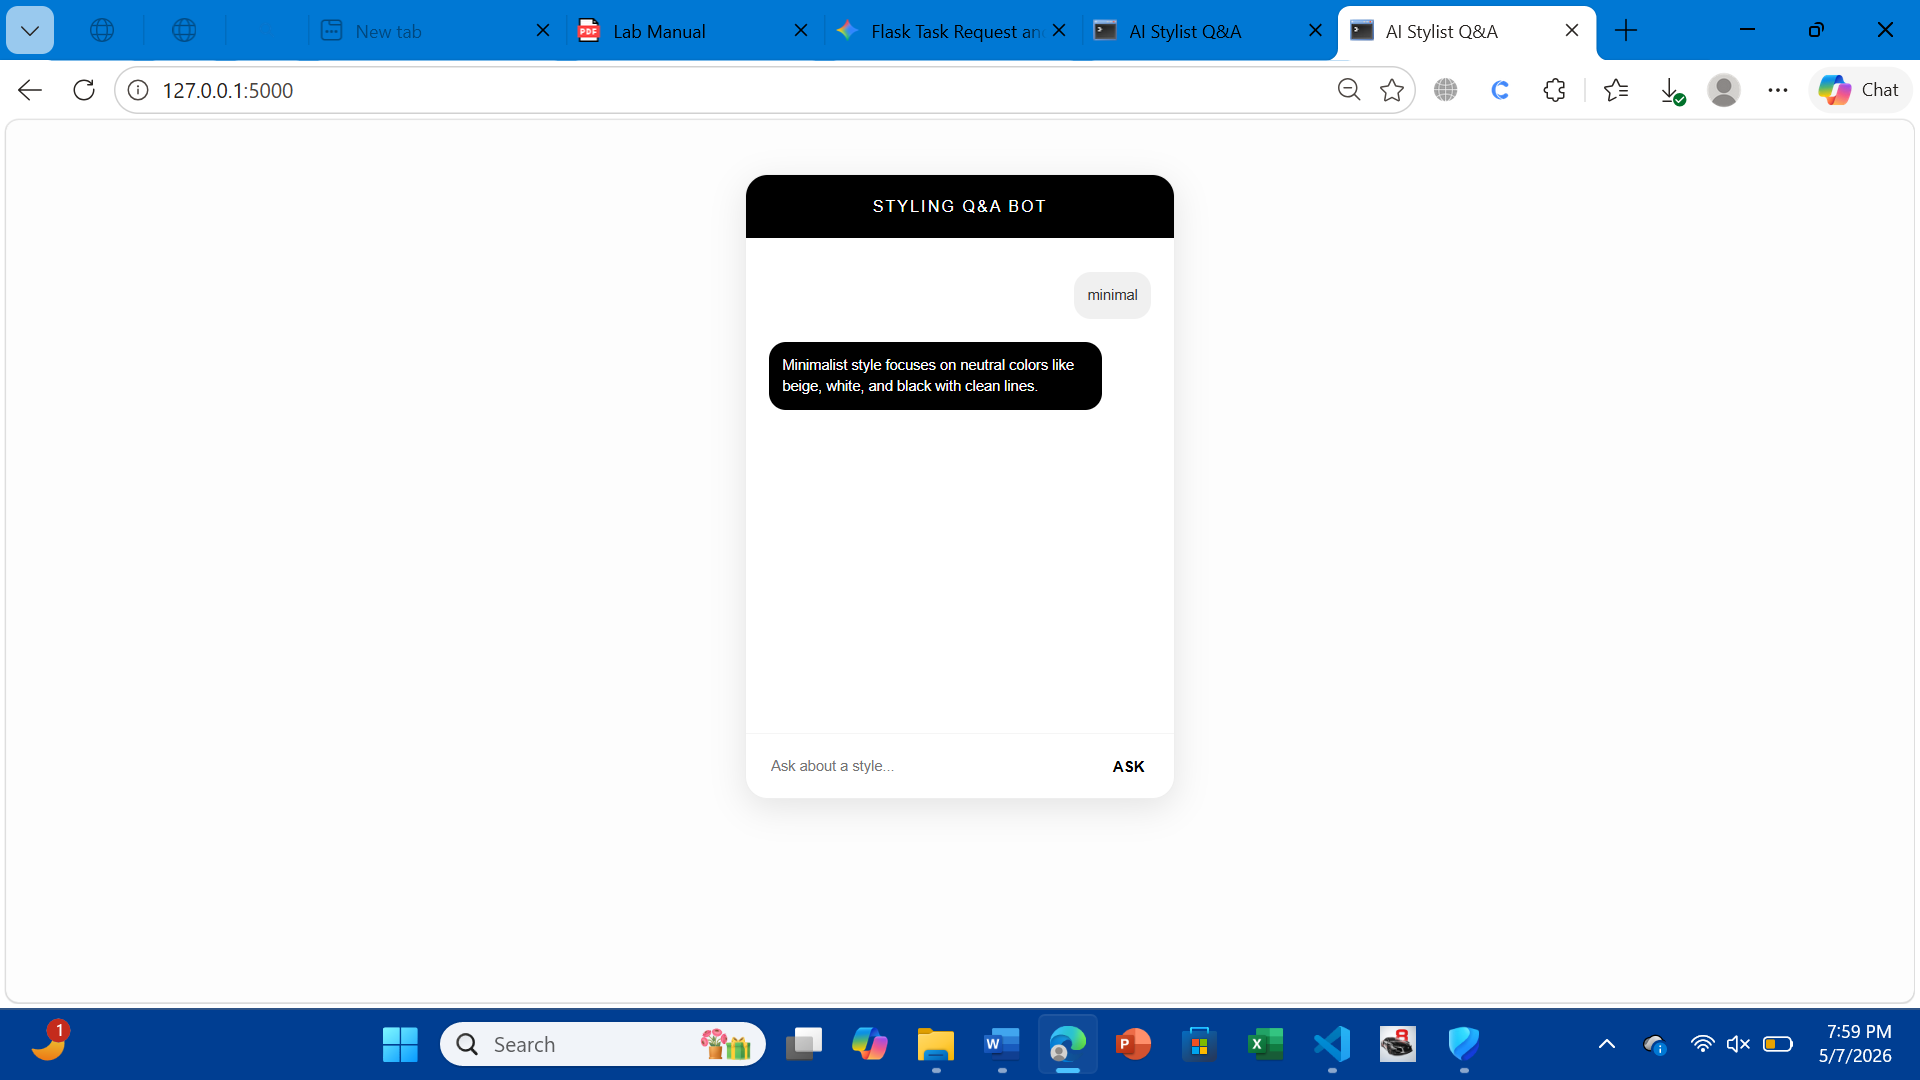

In [13]:
from IPython.display import Image, display

display(Image(filename='image.png.png' \
'', width=500))